# SAE Reading-Time Regression Results

This notebook summarizes the project through the SAE regression step. It is written for a research meeting: enough detail to defend the pipeline and results, without crowding the page with feature-ID tables before interpretation.

**Research question.** Do sparse autoencoder features from GPT-2-small residual-stream activations predict human reading times beyond lexical controls and GPT-2 surprisal?


## Current Answer

**Yes, in both datasets.** SAE features add held-out predictive signal beyond surprisal. The strongest layer is **Layer 3** in both Provo and Natural Stories.

| Dataset         |   Words |   Best SAE layer |   Controls R2 |   Controls + surprisal R2 |   Best SAE combined R2 |   Delta R2: surprisal over controls |   Delta R2: SAE over surprisal | SAE delta 95% CI   |   Stable features |
|:----------------|--------:|-----------------:|--------------:|--------------------------:|-----------------------:|------------------------------------:|-------------------------------:|:-------------------|------------------:|
| Natural Stories |   10246 |                3 |         0.133 |                     0.169 |                  0.276 |                               0.036 |                          0.107 | [0.079, 0.132]     |                79 |
| Provo           |    2630 |                3 |         0.146 |                     0.153 |                  0.202 |                               0.007 |                          0.049 | [0.033, 0.063]     |                58 |

## Data and Extraction Checks

Before interpreting the regression, the extraction quality matters. These checks are the reason the SAE regression is now interpretable.

| Dataset         |   Surprisal rows |   Surprisal NaNs |   Mean surprisal | SAE mean L0 range   | SAE mean rel. recon error range   |
|:----------------|-----------------:|-----------------:|-----------------:|:--------------------|:----------------------------------|
| Provo           |             2685 |               55 |            6.235 | 12.7-78.4           | 0.044-0.297                       |
| Natural Stories |            10256 |               10 |            5.408 | 10.7-81.5           | 0.048-0.325                       |

Notes:

- Surprisal NaNs are expected: one per Provo text and one per Natural Stories story because the first token has no left context under the no-BOS setup.
- Natural Stories hidden states were extracted with a 128-token context for SAE compatibility, while surprisal keeps long-context extraction.
- The SAE L0 and reconstruction-error ranges are now comparable across datasets, so the earlier Natural Stories OOD issue is fixed.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
DATASET_ORDER = ['Provo', 'Natural Stories']

# Consistent, colorblind-safe palette across the notebook.
# Dataset identity: Provo is always blue; Natural Stories is always orange.
COLORS = {
    'Provo': '#0072B2',            # Okabe-Ito blue
    'Natural Stories': '#D55E00',  # Okabe-Ito vermillion
}

# Numeric heatmaps: the same sequential scale everywhere; darker means larger.
HEATMAP_CMAP = 'cividis'

provo = pd.read_csv(PROJECT_ROOT / 'results/regression/provo_sae_regression.csv')
ns = pd.read_csv(PROJECT_ROOT / 'results/regression/natural_stories_sae_regression.csv')
results = pd.concat([provo, ns], ignore_index=True)
results['dataset'] = results['corpus'].map({'provo': 'Provo', 'natural_stories': 'Natural Stories'})

# Shared value ranges for comparable table shading.
GLOBAL_HEAT_RANGES = {
    'Controls R²': (0, float(results['heldout_r2_controls'].max())),
    'Controls + surprisal R²': (0, float(results['heldout_r2_controls_surprisal'].max())),
    'Combined R²': (0, float(results['heldout_r2_combined'].max())),
    'ΔR² surprisal': (0, float(results['heldout_delta_r2_surprisal'].max())),
    'ΔR² SAE': (0, float(results['heldout_delta_r2_sae_over_surprisal'].max())),
    'Stable features': (0, float(results['n_sae_features_selected_stable_60pct'].max())),
}

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)


def show_heat_table(df, heat_cols, caption=None, precision=4, ranges=None):
    """Display a numeric table with consistent colorblind-safe heatmap shading."""
    ranges = ranges or {}
    styler = df.style.format(precision=precision)
    for col in heat_cols:
        if col in df.columns:
            vmin, vmax = ranges.get(col, (None, None))
            styler = styler.background_gradient(cmap=HEATMAP_CMAP, subset=[col], vmin=vmin, vmax=vmax)
    styler = (
        styler
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', '600')]},
            {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-weight', '600'), ('font-size', '14px')]},
        ])
    )
    if caption:
        styler = styler.set_caption(caption)
    display(styler)

plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


## Color Convention

The notebook uses one consistent palette: **Provo is blue**, **Natural Stories is orange**, and numeric heatmaps use the same colorblind-safe **cividis** scale where darker cells mean larger values. For the SAE-gain tables and heatmaps, the color range is fixed across datasets so the same ΔR² value receives the same shade.

In [2]:
# Best-layer numeric summary: heatmap shading makes the main gains easy to compare.
best_rows = []
for dataset, df in results.groupby('dataset'):
    best = df.loc[df['heldout_delta_r2_sae_over_surprisal'].idxmax()]
    best_rows.append({
        'Dataset': dataset,
        'Words': int(best['n_words']),
        'Best layer': int(best['layer']),
        'Controls R²': best['heldout_r2_controls'],
        'Controls + surprisal R²': best['heldout_r2_controls_surprisal'],
        'Combined R²': best['heldout_r2_combined'],
        'ΔR² surprisal': best['heldout_delta_r2_surprisal'],
        'ΔR² SAE': best['heldout_delta_r2_sae_over_surprisal'],
        'SAE CI low': best['delta_sae_over_surprisal_ci_low'],
        'SAE CI high': best['delta_sae_over_surprisal_ci_high'],
        'Stable features': int(best['n_sae_features_selected_stable_60pct']),
    })

best_summary = pd.DataFrame(best_rows)
best_summary['Dataset'] = pd.Categorical(best_summary['Dataset'], categories=DATASET_ORDER, ordered=True)
best_summary = best_summary.sort_values('Dataset').reset_index(drop=True)

show_heat_table(
    best_summary,
    heat_cols=['Controls R²', 'Controls + surprisal R²', 'Combined R²', 'ΔR² surprisal', 'ΔR² SAE', 'Stable features'],
    ranges=GLOBAL_HEAT_RANGES,
    caption='Best SAE layer per dataset. Darker cells indicate larger values on a shared color scale.',
)


,Dataset,Words,Best layer,Controls R²,Controls + surprisal R²,Combined R²,ΔR² surprisal,ΔR² SAE,SAE CI low,SAE CI high,Stable features
0,Provo,2630,3,0.1457,0.1530,0.2021,0.0073,0.0491,0.0334,0.0633,58
1,Natural Stories,10246,3,0.1331,0.1692,0.2759,0.0361,0.1066,0.0791,0.1323,79


## Layer-wise Results

These tables are the main numerical evidence. The column to focus on is **Delta R2 SAE over surprisal**. Positive values mean the SAE feature model improves held-out prediction beyond the controls + surprisal baseline.


### Natural Stories

|   Layer |   R2 controls + surprisal |   R2 combined |   Delta R2 SAE over surprisal |   CI low |   CI high |   Stable features |
|--------:|--------------------------:|--------------:|------------------------------:|---------:|----------:|------------------:|
|       1 |                    0.1692 |        0.2345 |                        0.0653 |   0.0386 |    0.0872 |                50 |
|       2 |                    0.1692 |        0.2639 |                        0.0947 |   0.068  |    0.1204 |                77 |
|       3 |                    0.1692 |        0.2759 |                        0.1066 |   0.0791 |    0.1323 |                79 |
|       4 |                    0.1692 |        0.2484 |                        0.0792 |   0.0374 |    0.1127 |                92 |
|       5 |                    0.1692 |        0.249  |                        0.0798 |   0.0526 |    0.1049 |               100 |
|       6 |                    0.1692 |        0.2195 |                        0.0503 |  -0.0036 |    0.0925 |                99 |
|       7 |                    0.1692 |        0.2196 |                        0.0504 |   0.0071 |    0.085  |               110 |
|       8 |                    0.1692 |        0.2235 |                        0.0543 |   0.0226 |    0.0797 |                98 |
|       9 |                    0.1692 |        0.2302 |                        0.0609 |   0.0281 |    0.092  |               108 |
|      10 |                    0.1692 |        0.2203 |                        0.051  |   0.0048 |    0.0895 |               110 |
|      11 |                    0.1692 |        0.1892 |                        0.02   |  -0.0184 |    0.051  |                92 |
|      12 |                    0.1692 |        0.1866 |                        0.0173 |  -0.0208 |    0.0588 |                43 |

### Provo

|   Layer |   R2 controls + surprisal |   R2 combined |   Delta R2 SAE over surprisal |   CI low |   CI high |   Stable features |
|--------:|--------------------------:|--------------:|------------------------------:|---------:|----------:|------------------:|
|       1 |                     0.153 |        0.1932 |                        0.0402 |   0.026  |    0.0545 |                27 |
|       2 |                     0.153 |        0.192  |                        0.039  |   0.0267 |    0.0516 |                35 |
|       3 |                     0.153 |        0.2021 |                        0.0491 |   0.0334 |    0.0633 |                58 |
|       4 |                     0.153 |        0.1912 |                        0.0382 |   0.0236 |    0.0526 |                85 |
|       5 |                     0.153 |        0.1691 |                        0.0161 |  -0.002  |    0.0336 |                43 |
|       6 |                     0.153 |        0.174  |                        0.021  |   0.0097 |    0.0327 |                39 |
|       7 |                     0.153 |        0.1602 |                        0.0072 |  -0.0035 |    0.0184 |                28 |
|       8 |                     0.153 |        0.162  |                        0.0089 |   0.0006 |    0.0176 |                24 |
|       9 |                     0.153 |        0.1598 |                        0.0068 |  -0.0008 |    0.0144 |                19 |
|      10 |                     0.153 |        0.155  |                        0.002  |  -0.0069 |    0.0107 |                22 |
|      11 |                     0.153 |        0.1633 |                        0.0103 |  -0.0008 |    0.0194 |                17 |
|      12 |                     0.153 |        0.1673 |                        0.0143 |   0.0084 |    0.0202 |                10 |

In [3]:
# Full layer-wise tables: the ΔR² SAE column is the main result to read vertically.
layer_table = results[[
    'dataset', 'layer',
    'heldout_r2_controls_surprisal',
    'heldout_r2_combined',
    'heldout_delta_r2_sae_over_surprisal',
    'delta_sae_over_surprisal_ci_low',
    'delta_sae_over_surprisal_ci_high',
    'n_sae_features_selected_stable_60pct',
]].copy()

layer_table = layer_table.rename(columns={
    'dataset': 'Dataset',
    'layer': 'Layer',
    'heldout_r2_controls_surprisal': 'Controls + surprisal R²',
    'heldout_r2_combined': 'Combined R²',
    'heldout_delta_r2_sae_over_surprisal': 'ΔR² SAE',
    'delta_sae_over_surprisal_ci_low': 'CI low',
    'delta_sae_over_surprisal_ci_high': 'CI high',
    'n_sae_features_selected_stable_60pct': 'Stable features',
})

for dataset in DATASET_ORDER:
    display(Markdown(f'#### {dataset}'))
    df = layer_table[layer_table['Dataset'] == dataset].drop(columns=['Dataset']).sort_values('Layer')
    show_heat_table(
        df,
        heat_cols=['Combined R²', 'ΔR² SAE', 'Stable features'],
        ranges=GLOBAL_HEAT_RANGES,
        caption=f'{dataset}: layer-wise held-out fit and SAE gain. Darker cells use the same scale across datasets.',
    )


#### Provo

,Layer,Controls + surprisal R²,Combined R²,ΔR² SAE,CI low,CI high,Stable features
0,1,0.1530,0.1932,0.0402,0.0260,0.0545,27
1,2,0.1530,0.1920,0.0390,0.0267,0.0516,35
2,3,0.1530,0.2021,0.0491,0.0334,0.0633,58
3,4,0.1530,0.1912,0.0382,0.0236,0.0526,85
4,5,0.1530,0.1691,0.0161,-0.0020,0.0336,43
5,6,0.1530,0.1740,0.0210,0.0097,0.0327,39
6,7,0.1530,0.1602,0.0072,-0.0035,0.0184,28
7,8,0.1530,0.1620,0.0089,0.0006,0.0176,24
8,9,0.1530,0.1598,0.0068,-0.0008,0.0144,19
9,10,0.1530,0.1550,0.0020,-0.0069,0.0107,22


#### Natural Stories

,Layer,Controls + surprisal R²,Combined R²,ΔR² SAE,CI low,CI high,Stable features
12,1,0.1692,0.2345,0.0653,0.0386,0.0872,50
13,2,0.1692,0.2639,0.0947,0.0680,0.1204,77
14,3,0.1692,0.2759,0.1066,0.0791,0.1323,79
15,4,0.1692,0.2484,0.0792,0.0374,0.1127,92
16,5,0.1692,0.2490,0.0798,0.0526,0.1049,100
17,6,0.1692,0.2195,0.0503,-0.0036,0.0925,99
18,7,0.1692,0.2196,0.0504,0.0071,0.0850,110
19,8,0.1692,0.2235,0.0543,0.0226,0.0797,98
20,9,0.1692,0.2302,0.0609,0.0281,0.0920,108
21,10,0.1692,0.2203,0.0510,0.0048,0.0895,110


## Compact Gain Heatmap

This heatmap is the fastest visual summary for the meeting: each cell is the held-out ΔR² from adding SAE features beyond lexical controls and surprisal. The strongest result in both datasets is layer 3.

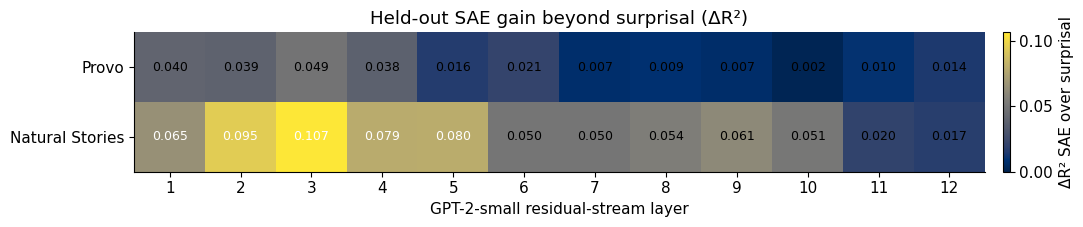

In [4]:
gain = results.pivot_table(
    index='dataset',
    columns='layer',
    values='heldout_delta_r2_sae_over_surprisal',
)
gain = gain.loc[DATASET_ORDER, list(range(1, 13))]

fig, ax = plt.subplots(figsize=(11, 2.4))
im = ax.imshow(
    gain.to_numpy(),
    aspect='auto',
    cmap=HEATMAP_CMAP,
    vmin=GLOBAL_HEAT_RANGES['ΔR² SAE'][0],
    vmax=GLOBAL_HEAT_RANGES['ΔR² SAE'][1],
)

ax.set_xticks(np.arange(gain.shape[1]))
ax.set_xticklabels(gain.columns)
ax.set_yticks(np.arange(gain.shape[0]))
ax.set_yticklabels(gain.index)
ax.set_xlabel('GPT-2-small residual-stream layer')
ax.set_title('Held-out SAE gain beyond surprisal (ΔR²)')

for i in range(gain.shape[0]):
    for j in range(gain.shape[1]):
        val = gain.iloc[i, j]
        text_color = 'white' if val > GLOBAL_HEAT_RANGES['ΔR² SAE'][1] * 0.58 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', color=text_color, fontsize=9)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('ΔR² SAE over surprisal')
fig.tight_layout()
plt.show()


## Figure: Layer-wise SAE Gain

This is the key figure. It shows where SAE features add held-out predictive value beyond surprisal.

Interpretation:

- Both datasets peak at **Layer 3**.
- Natural Stories has the larger effect, likely because it has more tokens and richer syntactic/semantic variation.
- Provo still shows the same peak-layer pattern, which matters because it is a different reading paradigm.


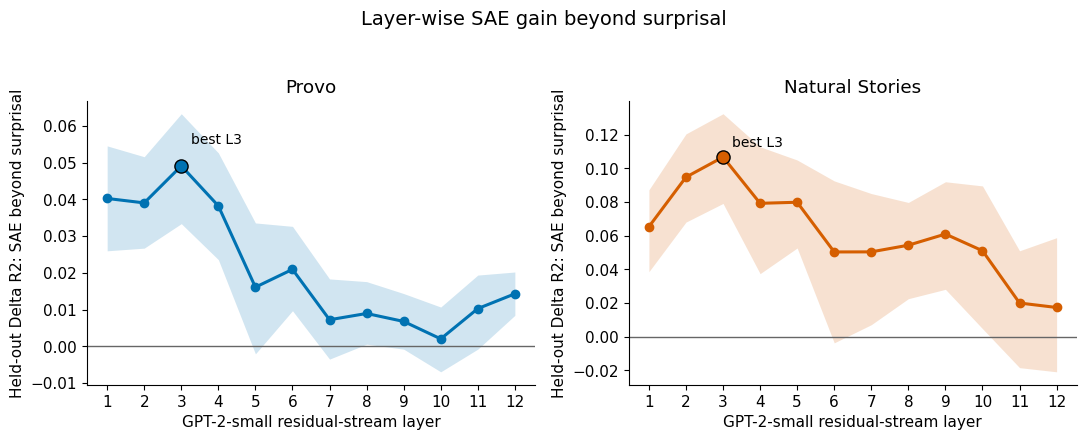

In [5]:
plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)
order = DATASET_ORDER

for ax, dataset in zip(axes, order):
    df = results[results['dataset'] == dataset].sort_values('layer')
    x = df['layer'].to_numpy()
    y = df['heldout_delta_r2_sae_over_surprisal'].to_numpy()
    lo = df['delta_sae_over_surprisal_ci_low'].to_numpy()
    hi = df['delta_sae_over_surprisal_ci_high'].to_numpy()
    color = COLORS[dataset]

    ax.axhline(0, color='#666666', linewidth=1)
    ax.fill_between(x, lo, hi, color=color, alpha=0.18, linewidth=0)
    ax.plot(x, y, color=color, marker='o', linewidth=2.2)

    best = df.loc[df['heldout_delta_r2_sae_over_surprisal'].idxmax()]
    ax.scatter(best['layer'], best['heldout_delta_r2_sae_over_surprisal'], s=90, color=color, edgecolor='black', zorder=3)
    ax.annotate(
        f"best L{int(best['layer'])}",
        xy=(best['layer'], best['heldout_delta_r2_sae_over_surprisal']),
        xytext=(best['layer'] + 0.25, best['heldout_delta_r2_sae_over_surprisal'] + 0.006),
        fontsize=10,
    )

    ax.set_title(dataset)
    ax.set_xlabel('GPT-2-small residual-stream layer')
    ax.set_ylabel('Held-out Delta R2: SAE beyond surprisal')
    ax.set_xticks(range(1, 13))

fig.suptitle('Layer-wise SAE gain beyond surprisal', y=1.04, fontsize=14)
fig.tight_layout()
plt.show()


## Figure: Feature-selection Stability

This is not the main performance result. It answers a practical question: where do we have enough stable features to interpret?

Interpretation:

- Natural Stories has many stable selected features across layers, especially layers 4-10.
- Provo has fewer stable features because it is smaller, but layers 3-4 still give interpretable candidates.
- For feature interpretation, start with Layer 3 because it is the strongest predictive layer in both datasets.


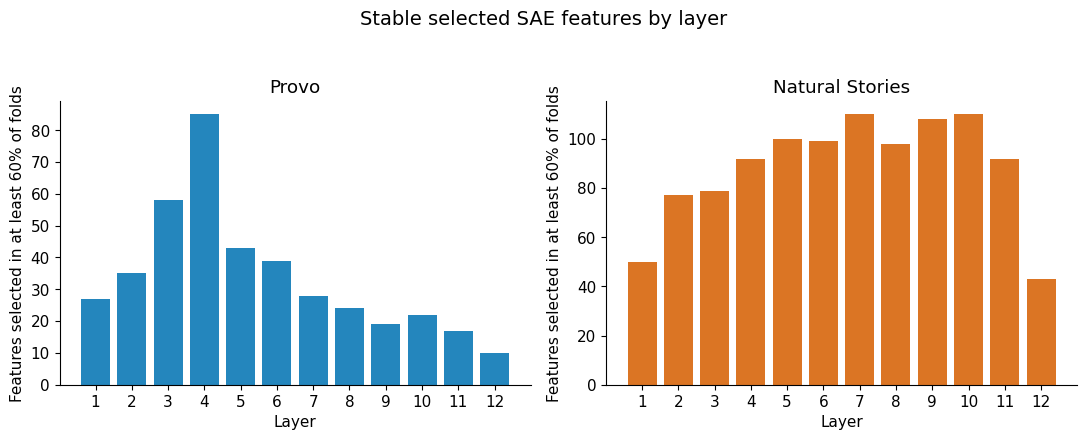

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)

for ax, dataset in zip(axes, DATASET_ORDER):
    df = results[results['dataset'] == dataset].sort_values('layer')
    color = COLORS[dataset]
    ax.bar(df['layer'], df['n_sae_features_selected_stable_60pct'], color=color, alpha=0.86)
    ax.set_title(dataset)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Features selected in at least 60% of folds')
    ax.set_xticks(range(1, 13))

fig.suptitle('Stable selected SAE features by layer', y=1.04, fontsize=14)
fig.tight_layout()
plt.show()


## Figure: SAE Feature Activation Percentage

This figure checks whether the SAE representation is actually sparse at the word level. For every word and layer, we compute:

**percentage active = active SAE features / total SAE features × 100**

The line shows the mean percentage across words. The shaded band shows the middle 50% of words. This is useful to report before feature interpretation because it shows how many SAE features are being used per word at each layer.

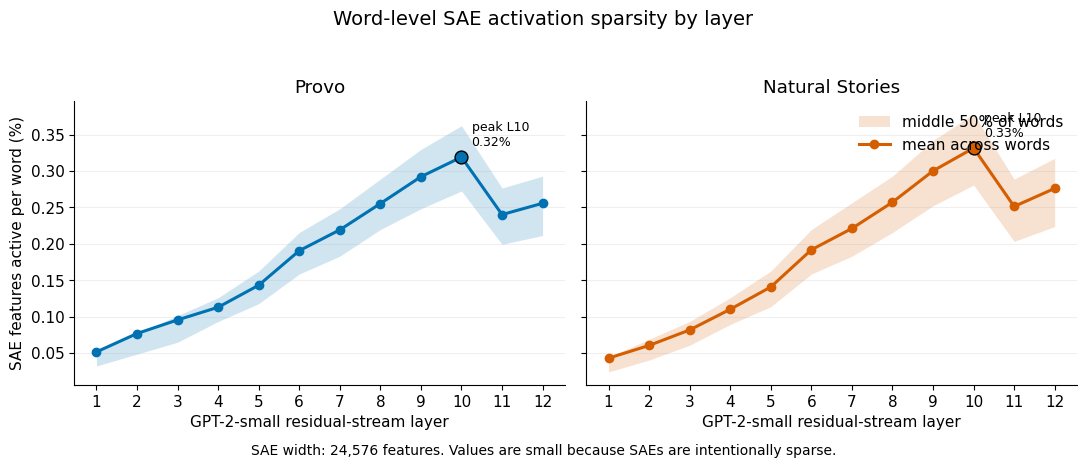

,Dataset,Layer,Mean active features/word,Median active features/word,Mean active %,Median active %,Word-layer rows,SAE width
0,Natural Stories,1,10.6514,8.0000,0.0433,0.0326,10246,24576
1,Natural Stories,2,14.9304,13.0000,0.0608,0.0529,10246,24576
2,Natural Stories,3,20.1503,19.0000,0.0820,0.0773,10246,24576
3,Natural Stories,4,27.1123,26.0000,0.1103,0.1058,10246,24576
4,Natural Stories,5,34.6312,34.0000,0.1409,0.1383,10246,24576
5,Natural Stories,6,47.1624,46.0000,0.1919,0.1872,10246,24576
6,Natural Stories,7,54.3548,54.0000,0.2212,0.2197,10246,24576
7,Natural Stories,8,63.2022,62.0000,0.2572,0.2523,10246,24576
8,Natural Stories,9,73.7643,73.0000,0.3001,0.2970,10246,24576
9,Natural Stories,10,81.4635,80.0000,0.3315,0.3255,10246,24576


In [7]:
# Activation sparsity by word and layer.
# The SAE-Lens GPT-2 small residual-stream SAEs used here have 24,576 dictionary features.
# We use the metadata CSVs so this notebook can rerun from compact GitHub-tracked outputs,
# without requiring the large sparse activation arrays.
SAE_WIDTH = 24_576

activation_frames = []
for corpus, dataset in [('provo', 'Provo'), ('natural_stories', 'Natural Stories')]:
    meta = pd.read_csv(PROJECT_ROOT / f'results/sae/{corpus}_sae_metadata.csv')
    meta['Dataset'] = dataset
    meta['SAE width'] = SAE_WIDTH
    meta['Active %'] = meta['n_active'] / SAE_WIDTH * 100
    activation_frames.append(meta[['Dataset', 'layer', 'n_active', 'Active %', 'SAE width']])

activation = pd.concat(activation_frames, ignore_index=True)
activation_summary = (
    activation
    .groupby(['Dataset', 'layer'], as_index=False)
    .agg(
        mean_active_features=('n_active', 'mean'),
        median_active_features=('n_active', 'median'),
        q25_active_features=('n_active', lambda x: x.quantile(0.25)),
        q75_active_features=('n_active', lambda x: x.quantile(0.75)),
        mean_active_pct=('Active %', 'mean'),
        median_active_pct=('Active %', 'median'),
        q25_active_pct=('Active %', lambda x: x.quantile(0.25)),
        q75_active_pct=('Active %', lambda x: x.quantile(0.75)),
        words=('n_active', 'size'),
        sae_width=('SAE width', 'first'),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

for ax, dataset in zip(axes, DATASET_ORDER):
    df = activation_summary[activation_summary['Dataset'] == dataset].sort_values('layer')
    x = df['layer'].to_numpy()
    mean = df['mean_active_pct'].to_numpy()
    q25 = df['q25_active_pct'].to_numpy()
    q75 = df['q75_active_pct'].to_numpy()
    color = COLORS[dataset]

    ax.fill_between(x, q25, q75, color=color, alpha=0.18, linewidth=0, label='middle 50% of words')
    ax.plot(x, mean, color=color, marker='o', linewidth=2.2, label='mean across words')

    peak = df.loc[df['mean_active_pct'].idxmax()]
    ax.scatter(peak['layer'], peak['mean_active_pct'], s=85, color=color, edgecolor='black', zorder=3)
    ax.annotate(
        f"peak L{int(peak['layer'])}\n{peak['mean_active_pct']:.2f}%",
        xy=(peak['layer'], peak['mean_active_pct']),
        xytext=(peak['layer'] + 0.25, peak['mean_active_pct'] + 0.015),
        fontsize=9,
    )

    ax.set_title(dataset)
    ax.set_xlabel('GPT-2-small residual-stream layer')
    ax.set_xticks(range(1, 13))
    ax.grid(axis='y', alpha=0.2)

axes[0].set_ylabel('SAE features active per word (%)')
axes[1].legend(frameon=False, loc='upper right')
fig.suptitle('Word-level SAE activation sparsity by layer', y=1.04, fontsize=14)
fig.text(0.5, -0.02, 'SAE width: 24,576 features. Values are small because SAEs are intentionally sparse.', ha='center', fontsize=10)
fig.tight_layout()
plt.show()

# Numeric version of the plotted summary.
activation_table = activation_summary[[
    'Dataset', 'layer', 'mean_active_features', 'median_active_features',
    'mean_active_pct', 'median_active_pct', 'words', 'sae_width'
]].rename(columns={
    'layer': 'Layer',
    'mean_active_features': 'Mean active features/word',
    'median_active_features': 'Median active features/word',
    'mean_active_pct': 'Mean active %',
    'median_active_pct': 'Median active %',
    'words': 'Word-layer rows',
    'sae_width': 'SAE width',
})

show_heat_table(
    activation_table,
    heat_cols=['Mean active features/word', 'Median active features/word', 'Mean active %', 'Median active %'],
    caption='Numeric summary behind the activation figure. Darker cells indicate more SAE features active per word.',
)


## Candidate Features for Interpretation

These are not interpretations yet. They are candidates for the next stage. I would present them only if asked what comes next.

Selection rule used below:

- Use the best layer for each dataset.
- Keep features selected in every outer fold, with consistent coefficient sign.
- Rank by absolute coefficient magnitude.


In [8]:
candidate_tables = []
for corpus, dataset in [('provo', 'Provo'), ('natural_stories', 'Natural Stories')]:
    top = pd.read_csv(PROJECT_ROOT / f'results/regression/{corpus}_sae_top_features.csv')
    best_layer = int(best_summary.loc[best_summary['Dataset'] == dataset, 'Best layer'].iloc[0])
    cand = top[(top['layer'] == best_layer) & (top['selection_rate'] == 1.0) & (top['sign_agreement'] == 1.0)].copy()
    cand['abs_coef'] = cand['coef'].abs()
    cand = cand.sort_values('abs_coef', ascending=False).head(12)
    cand = cand[['layer', 'feature_id', 'coef', 'abs_coef', 'direction', 'pct_active', 'selection_rate', 'sign_agreement']]
    cand = cand.rename(columns={
        'layer': 'Layer',
        'feature_id': 'Feature ID',
        'coef': 'Coefficient',
        'abs_coef': '|Coefficient|',
        'direction': 'Direction',
        'pct_active': '% active',
        'selection_rate': 'Selection rate',
        'sign_agreement': 'Sign agreement',
    })
    candidate_tables.append((dataset, cand))

feature_ranges = {
    '|Coefficient|': (0, max(float(c['|Coefficient|'].max()) for _, c in candidate_tables if len(c))),
    '% active': (0, max(float(c['% active'].max()) for _, c in candidate_tables if len(c))),
    'Selection rate': (0, 1),
    'Sign agreement': (0, 1),
}

for dataset, cand in candidate_tables:
    display(Markdown(f'#### {dataset}: stable candidate features from the best layer'))
    show_heat_table(
        cand,
        heat_cols=['|Coefficient|', '% active', 'Selection rate', 'Sign agreement'],
        ranges=feature_ranges,
        caption='Candidate features to inspect next. Coefficient sign shows direction; shading uses magnitude and stability.',
    )


#### Provo: stable candidate features from the best layer

,Layer,Feature ID,Coefficient,|Coefficient|,Direction,% active,Selection rate,Sign agreement
106,3,3990,0.0109,0.0109,positive,3.5361,1.0000,1.0000
107,3,14509,-0.0072,0.0072,negative,3.4601,1.0000,1.0000
108,3,15739,-0.0072,0.0072,negative,9.2776,1.0000,1.0000
110,3,18231,-0.0055,0.0055,negative,4.4106,1.0000,1.0000
111,3,24460,-0.0053,0.0053,negative,0.9506,1.0000,1.0000
112,3,10596,0.0045,0.0045,positive,7.0342,1.0000,1.0000
113,3,2111,-0.0043,0.0043,negative,0.6844,1.0000,1.0000
117,3,352,0.0040,0.0040,positive,13.4601,1.0000,1.0000
126,3,3970,0.0034,0.0034,positive,3.9163,1.0000,1.0000
146,3,19742,-0.0023,0.0023,negative,2.6996,1.0000,1.0000


#### Natural Stories: stable candidate features from the best layer

,Layer,Feature ID,Coefficient,|Coefficient|,Direction,% active,Selection rate,Sign agreement
219,3,24573,-0.0092,0.0092,negative,42.8753,1.0000,1.0000
220,3,12935,-0.0088,0.0088,negative,54.0699,1.0000,1.0000
221,3,2765,0.0076,0.0076,positive,2.8109,1.0000,1.0000
222,3,18381,0.0066,0.0066,positive,10.4041,1.0000,1.0000
223,3,9923,-0.0062,0.0062,negative,16.7675,1.0000,1.0000
224,3,16579,0.0047,0.0047,positive,0.5563,1.0000,1.0000
225,3,9407,-0.0046,0.0046,negative,13.6736,1.0000,1.0000
226,3,19303,0.0043,0.0043,positive,1.6689,1.0000,1.0000
227,3,9067,-0.0042,0.0042,negative,33.3203,1.0000,1.0000
228,3,12353,0.0040,0.0040,positive,1.2395,1.0000,1.0000


## Analysis for Meeting

### What the result says

The result supports the predictive claim: GPT-2-small SAE features contain reading-time-relevant information that is not captured by lexical controls or GPT-2 surprisal alone.

The strongest evidence is the replication of the best layer:

- Provo peaks at Layer 3 with Delta R2 about 0.049 beyond surprisal.
- Natural Stories peaks at Layer 3 with Delta R2 about 0.107 beyond surprisal.

This gives us a coherent target for feature interpretation rather than a fishing expedition across all 12 layers.

### Why Layer 3 is plausible

Layer 3 is early enough to retain lexical and local contextual information, but already contextualized by several transformer blocks. That makes it a reasonable place for features related to local semantic fit, syntactic setup, lexical ambiguity, or short-range integration cost.

I would avoid saying Layer 3 is “the comprehension layer.” The safer claim is: Layer 3 is where this SAE feature space adds the most held-out reading-time signal in both corpora.

### What not to overclaim

- This is predictive evidence, not causal evidence.
- The feature IDs are not meaningful until we inspect max-activating examples.
- A positive coefficient means the feature predicts longer reading times after controls, not that humans literally use that feature.
- The results justify feature interpretation, but they do not complete it.

### Recommended next step

Start with Layer 3 features that are stable across folds and have consistent coefficient signs. For each feature, collect max-activating token contexts, label the linguistic pattern, then check whether that pattern makes psycholinguistic sense.


## Short Meeting Script

I fixed the preprocessing first because the initial Natural Stories SAE activations were out of distribution. After switching Natural Stories hidden-state extraction to the SAE-compatible context length, the SAE reconstruction quality became comparable across the two corpora.

Then I ran grouped held-out regressions. Surprisal improves prediction over lexical controls, which is expected. The SAE result is the main finding: SAE features improve held-out reading-time prediction beyond surprisal in both datasets. The best layer is Layer 3 in both Provo and Natural Stories.

I think this is enough to move to feature interpretation, but I would start narrowly: stable Layer 3 features first, then compare nearby layers 2 and 4 if needed.
